# 11 · Brandenburg State-Wide Mass Forecasting Engine

Batch 24h-ahead wind & solar generation forecast for **all 18 Kreise** of
Brandenburg — the 14 Landkreise + 4 kreisfreie Städte — scaling the calibrated
municipal pilot into a state-wide predictive engine.

**Per district the pipeline:**
1. assigns every *active* MaStR asset to its district by **point-in-polygon**
   (MaStR has no Kreis field; boundaries come from Nominatim, cached), and
   aggregates the local wind / solar nameplate,
2. fetches **live Open-Meteo forecast** weather for that district's 0.1° grid nodes
   (sequential, with backoff for graceful rate-limiting),
3. computes the physics-informed CF priors + features (the *same* builder used in
   validation), runs the **LightGBM quantile** models (P10/P50/P90),
4. downscales with `CF × nameplate × k`. No district has validation telemetry, so
   the calibration falls back to **identity (scale 1.0, offset 0.0)** — trust the
   physics. (`offset` is an absolute-kW term fit to a tiny Gemeinde and does not
   transfer to a Landkreis; the pilot scales diverge too much to pool, so identity
   is the honest default. `pooled` scale is available in `resolve_calibration`.)

Output: one tidy multi-index (`district`, `time_utc`) Parquet in `results/forecasts/`.

In [1]:
import os, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.districts import load_district_fleets, load_district_boundaries
from src.dashboard.forecast_service import forecast_district

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
FALLBACK_MODE = "identity"   # see resolve_calibration(); 'pooled' is the sensitivity knob
HORIZON_H = 24
OUT_PATH = "results/forecasts/brandenburg_state_forecast.parquet"

## 1 · Geospatial target registry & fleet aggregation

Active installed capacity per district, from the point-in-polygon assignment.

In [2]:
boundaries = load_district_boundaries()
fleets = load_district_fleets()   # {name: (wind, solar, wind_mw, solar_mw, nodes)}

registry = pd.DataFrame([
    {"district": n, "kind": boundaries.set_index('name').loc[n, 'kind'],
     "wind_mw": round(f[2], 1), "solar_mw": round(f[3], 1),
     "n_wind": len(f[0]), "n_solar": len(f[1]), "n_nodes": len(f[4])}
    for n, f in fleets.items()
]).sort_values("wind_mw", ascending=False).reset_index(drop=True)
print(f"{len(registry)} districts | state wind {registry.wind_mw.sum():.0f} MW, "
      f"solar {registry.solar_mw.sum():.0f} MW")
registry

2026-07-02 19:52:06,393 - INFO - Configuration loaded successfully from conf/config.yaml


2026-07-02 19:52:06,467 - INFO - Configuration loaded successfully from conf/config.yaml


2026-07-02 19:52:06,471 - INFO - Configuration loaded successfully from conf/config.yaml


2026-07-02 19:52:06,529 - INFO - Configuration loaded successfully from conf/config.yaml


2026-07-02 19:52:06,893 - INFO - Barnim: wind 399.3 MW (156), solar 552.2 MW (13406), 26 nodes


...

2026-07-02 19:52:06,954 - INFO - Potsdam: wind 0.0 MW (1), solar 47.4 MW (3768), 5 nodes


2026-07-02 19:52:06,957 - INFO - Cottbus: wind 64.0 MW (32), solar 74.8 MW (3990), 5 nodes


2026-07-02 19:52:06,959 - INFO - Frankfurt (Oder): wind 21.6 MW (13), solar 53.2 MW (2052), 4 nodes


18 districts | state wind 9570 MW, solar 9055 MW


,district,kind,wind_mw,solar_mw,n_wind,n_solar,n_nodes
0,Uckermark,landkreis,1755.6,658.9,683,7487,52
1,Prignitz,landkreis,1316.0,593.6,590,5043,37
2,Teltow-Fläming,landkreis,868.8,565.4,398,13509,38
3,Märkisch-Oderland,landkreis,804.5,1470.1,315,15796,38
4,Dahme-Spreewald,landkreis,785.1,553.1,318,12593,42
5,Elbe-Elster,landkreis,654.2,556.4,332,9242,36
6,Potsdam-Mittelmark,landkreis,558.9,435.7,236,18842,48
7,Oder-Spree,landkreis,504.9,383.2,178,13183,42
8,Ostprignitz-Ruppin,landkreis,497.9,578.5,313,6888,42
9,Oberspreewald-Lausitz,landkreis,487.0,786.5,174,7592,23


## 2 · Batch inference — live forecast for all 18 districts

Sequential calls with a polite pause between districts; `fetch_forecast_weather`
retries with exponential backoff on 429/5xx so the run degrades gracefully under
rate-limiting. All timestamps are tz-aware UTC — no local-time drift on aggregation.

In [3]:
frames = []
for i, (name, fleet) in enumerate(fleets.items(), 1):
    try:
        fc, caps, used = forecast_district(name, fleet, mode=FALLBACK_MODE,
                                           horizon_h=HORIZON_H, pause=1.0)
    except Exception as e:
        print(f"  [{i:2d}/18] {name:26s} FAILED: {e}")
        continue
    fc = fc.copy()
    fc["wind_nameplate_mw"] = round(caps["wind"], 3)
    fc["solar_nameplate_mw"] = round(caps["solar"], 3)
    fc.insert(0, "district", name)
    fc.index.name = "time_utc"
    frames.append(fc.reset_index())
    print(f"  [{i:2d}/18] {name:26s} ok  wind P50 peak {fc['wind_median_mw'].max():6.1f} MW  "
          f"solar {fc['solar_median_mw'].max():6.1f} MW")

state = pd.concat(frames, ignore_index=True)
print(f"\nCollected {state.district.nunique()} districts x {HORIZON_H} h = {len(state)} rows")

2026-07-02 19:52:06,978 - INFO - Configuration loaded successfully from conf/config.yaml


2026-07-02 19:52:08,112 - INFO - Configuration loaded successfully from conf/config.yaml


2026-07-02 19:52:09,904 - WARNING - Poor match score for turbine 'Generic' (mfr ID: None). Falling back to closest capacity match in database: 'Northern Power Systems NPS 100C-24' (95.0 kW vs registered 4.6 kW).


2026-07-02 19:52:10,467 - INFO - Configuration loaded successfully from conf/config.yaml


  [ 1/18] Barnim                     ok  wind P50 peak  303.8 MW  solar  384.4 MW


...

2026-07-02 19:53:24,080 - INFO - Configuration loaded successfully from conf/config.yaml


2026-07-02 19:53:24,599 - INFO - Configuration loaded successfully from conf/config.yaml


  [17/18] Cottbus                    ok  wind P50 peak   46.2 MW  solar   46.1 MW


2026-07-02 19:53:25,683 - INFO - Configuration loaded successfully from conf/config.yaml


  [18/18] Frankfurt (Oder)           ok  wind P50 peak   15.4 MW  solar   41.2 MW

Collected 18 districts x 24 h = 432 rows


## 3 · Integrity checks & export

Every district present, every series a clean 24 h UTC block, no gaps — then save the multi-index Parquet.

In [4]:
assert state["time_utc"].dt.tz is not None, "timestamps must be tz-aware (UTC)"
assert str(state["time_utc"].dt.tz) == "UTC", "timestamps must be UTC"
counts = state.groupby("district").size()
assert (counts == HORIZON_H).all(), f"uneven horizons: {counts[counts != HORIZON_H].to_dict()}"
assert not state.drop(columns='district').isna().any().any(), "unexpected NaNs in forecast"

state_mi = state.set_index(["district", "time_utc"]).sort_index()
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
state_mi.to_parquet(OUT_PATH)
print(f"Saved {state_mi.shape} multi-index forecast -> {OUT_PATH}")
state_mi.head(3)

Saved (432, 8) multi-index forecast -> results/forecasts/brandenburg_state_forecast.parquet


wind_lower_mw  wind_median_mw  \
district time_utc                                                   
Barnim   2026-07-02 20:00:00+00:00     241.572389      263.324823   
         2026-07-02 21:00:00+00:00     223.503906      252.045813   
         2026-07-02 22:00:00+00:00     263.318686      293.092488   

                                    wind_upper_mw  solar_lower_mw  \
district time_utc                                                   
Barnim   2026-07-02 20:00:00+00:00     294.733325             0.0   
         2026-07-02 21:00:00+00:00     279.762720             0.0   
         2026-07-02 22:00:00+00:00     309.343475             0.0   

                                    solar_median_mw  solar_upper_mw  \
district time_utc                                                     
Barnim   2026-07-02 20:00:00+00:00         0.000000        0.000000   
         2026-07-02 21:00:00+00:00         0.000625        0.142061   
         2026-07-02 22:00:00+00:00         0.000389        0.001219   

                                    wind_nameplate_mw  solar_nameplate_mw  
district time_utc                                                          
Barnim   2026-07-02 20:00:00+00:00            399.297             552.202  
         2026-07-02 21:00:00+00:00            399.297             552.202  
         2026-07-02 22:00:00+00:00            399.297             552.202

## 4 · Brandenburg total aggregate

Sum P10 / P50 / P90 across all 18 districts. **Caveat:** summing quantiles is the
*comonotonic* (perfect-correlation) aggregation, so the band is a **conservative
upper bound** on the true state-wide interval — real spatial forecast errors
partly decorrelate, which would narrow it.

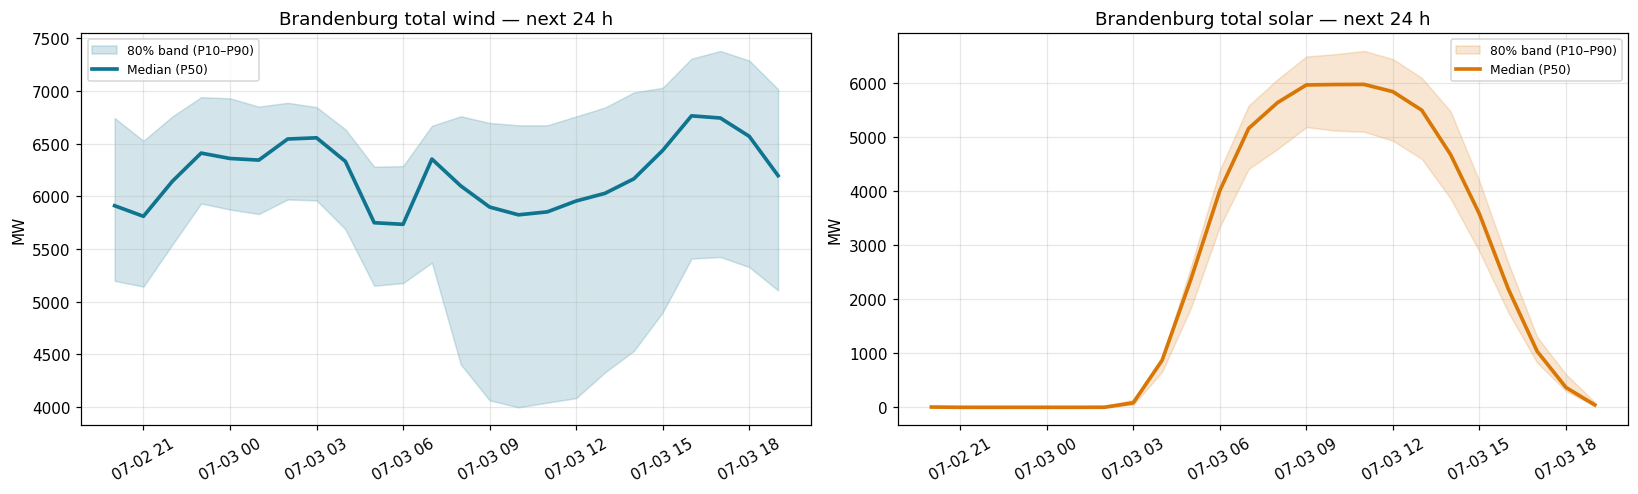

State peak wind (P50): 6763 MW | peak solar (P50): 5968 MW
24h wind energy (P50): 148773 MWh | solar: 59214 MWh


In [5]:
agg = state_mi.groupby(level="time_utc")[
    ["wind_lower_mw","wind_median_mw","wind_upper_mw",
     "solar_lower_mw","solar_median_mw","solar_upper_mw"]].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, tech, color in zip(axes, ("wind","solar"), ("#0e7490","#d97706")):
    ax.fill_between(agg.index, agg[f"{tech}_lower_mw"], agg[f"{tech}_upper_mw"],
                    color=color, alpha=0.18, label="80% band (P10–P90)")
    ax.plot(agg.index, agg[f"{tech}_median_mw"], color=color, lw=2.4, label="Median (P50)")
    ax.set_title(f"Brandenburg total {tech} — next {HORIZON_H} h"); ax.set_ylabel("MW")
    ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print(f"State peak wind (P50): {agg.wind_median_mw.max():.0f} MW | "
      f"peak solar (P50): {agg.solar_median_mw.max():.0f} MW")
print(f"24h wind energy (P50): {agg.wind_median_mw.sum():.0f} MWh | "
      f"solar: {agg.solar_median_mw.sum():.0f} MWh")

## 5 · Per-district peak generation

Where the next-24h generation concentrates — drives which feeders face the most balancing pressure.

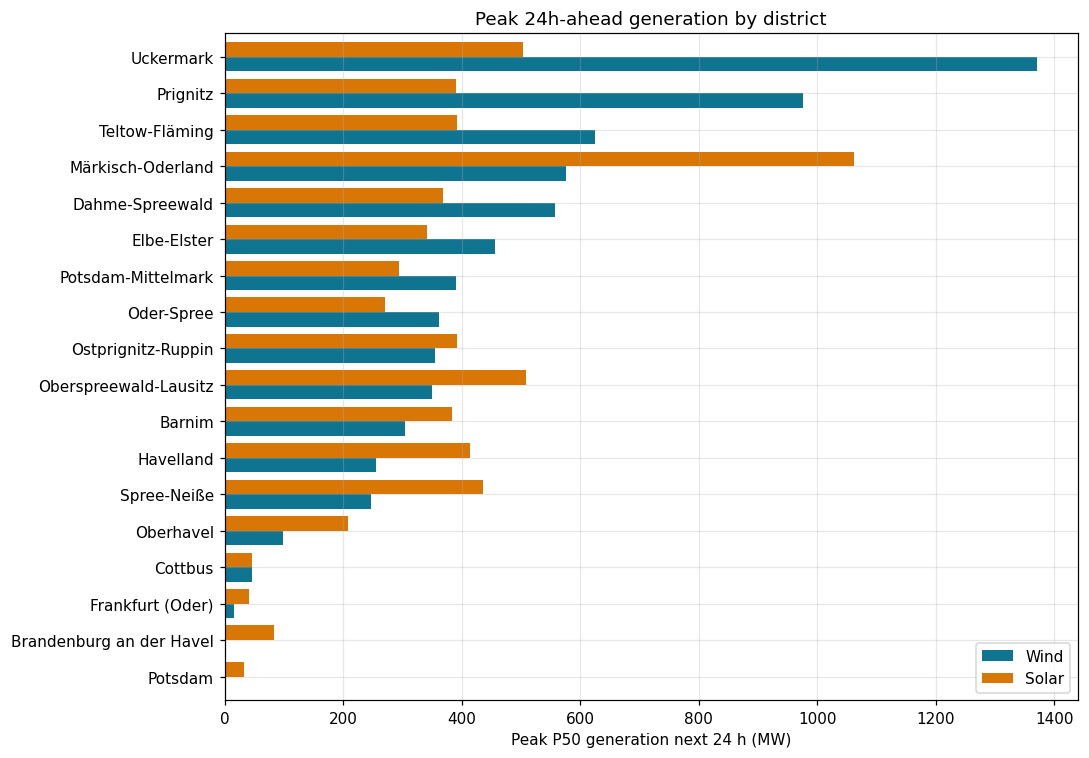

In [6]:
peak = (state_mi.groupby(level="district")[["wind_median_mw","solar_median_mw"]].max()
        .sort_values("wind_median_mw"))
ax = peak.plot.barh(figsize=(10, 7), color=["#0e7490","#d97706"], width=0.8)
ax.set_xlabel("Peak P50 generation next 24 h (MW)"); ax.set_ylabel("")
ax.set_title("Peak 24h-ahead generation by district"); ax.legend(["Wind","Solar"])
plt.tight_layout(); plt.show()

## Takeaways

- The engine scales the calibrated pilot to **all 18 Brandenburg Kreise** with no
  per-district code — assets are assigned geospatially and the *same* physics +
  quantile models run everywhere.
- Uncalibrated districts use **identity** downscaling (trust the physics). When
  DSO telemetry arrives for a district, fit its affine `(scale, offset)` and it
  slots in exactly like the pilot municipalities — no engine change.
- The state total curve + P10–P90 band is the operational view; remember the band
  is the conservative comonotonic sum. Re-run this notebook to refresh from live NWP.